# HW14 — Эмбеддинги, FAISS, оценка retrieval и mini-RAG

**Тема:** построение базы знаний, чанкинг, векторные представления, индекс FAISS, оценка retrieval, обновление базы знаний, mini-RAG.

**База знаний:** Солнечная система и космос — 15 документов о планетах, спутниках, кометах и истории космонавтики.

## 0. План

1. Импорты, seed, среда.
2. Загрузка базы знаний и sanity-check.
3. Чанкинг документов.
4. Эмбеддинги и индекс FAISS.
5. Контрольные запросы и оценка retrieval (`hit@k`, `recall@k`).
6. Эксперимент: сравнение двух значений `chunk_size`.
7. Обновление базы знаний и переиндексация.
8. Mini-RAG с возвратом источников.
9. Анализ ошибок.
10. Сохранение артефактов.

## 1. Импорты, seed и среда

In [ ]:
# Установка зависимостей (Google Colab).
!pip install -q faiss-cpu sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 49.2 MB/s eta 0:00:00


In [ ]:
import os
import re
import random
import json
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# sentence-transformers
try:
    from sentence_transformers import SentenceTransformer
    HAS_SBERT = True
except ImportError:
    HAS_SBERT = False

# FAISS
try:
    import faiss
    HAS_FAISS = True
except ImportError:
    HAS_FAISS = False

# sklearn — fallback
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

print(f"sentence-transformers: {HAS_SBERT}")
print(f"FAISS: {HAS_FAISS}")

sentence-transformers: True
FAISS: True


In [ ]:
# Фиксируем seed.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_seed(42)

# Устройство.
DEVICE = "cpu"
try:
    import torch
    if torch.cuda.is_available():
        DEVICE = "cuda"
        torch.manual_seed(42)
        torch.cuda.manual_seed_all(42)
except ImportError:
    pass

print(f"Device: {DEVICE}")

Device: cuda


In [ ]:
# Создаём папку для артефактов.
os.makedirs("artifacts", exist_ok=True)

## 2. База знаний и первичный анализ

**Предметная область:** Солнечная система и космос.

Это набор из 15 коротких текстовых документов о Солнце, планетах, спутниках, кометах, экзопланетах и истории космонавтики.
Тема хорошо подходит для retrieval и mini-RAG: документы покрывают различные факты, по которым удобно формулировать
конкретные вопросы с однозначно определёнными ответами.

In [ ]:
documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_01",
        "title": "Солнце",
        "text": (
            "Солнце — центральная звезда Солнечной системы, вокруг которой вращаются все планеты и другие тела. "
            "Это жёлтый карлик спектрального класса G2V. Масса Солнца составляет около 99,86% всей массы Солнечной системы. "
            "Температура на поверхности достигает примерно 5500 градусов Цельсия, а в ядре — около 15 миллионов градусов. "
            "Энергия Солнца образуется в результате термоядерного синтеза: водород превращается в гелий, высвобождая колоссальное количество энергии. "
            "Солнечный ветер — поток заряженных частиц — распространяется по всей Солнечной системе и влияет на магнитосферы планет. "
            "Магнитное поле Солнца меняет свою полярность примерно каждые 11 лет, что связано с циклом солнечной активности. "
            "Солнечные вспышки и корональные выбросы массы могут вызывать магнитные бури на Земле."
        ),
    },
    {
        "doc_id": "doc_02",
        "title": "Меркурий",
        "text": (
            "Меркурий — ближайшая к Солнцу и самая маленькая планета Солнечной системы. "
            "Его диаметр составляет всего 4879 километров. "
            "Из-за отсутствия значительной атмосферы перепады температур на поверхности огромны: "
            "днём температура поднимается до 430 градусов Цельсия, а ночью опускается до минус 180 градусов. "
            "Поверхность Меркурия покрыта кратерами и напоминает лунную. "
            "Один оборот вокруг Солнца Меркурий совершает за 88 земных суток, "
            "при этом один оборот вокруг своей оси занимает около 59 суток. "
            "Космический аппарат MESSENGER изучал Меркурий с орбиты в 2011–2015 годах "
            "и обнаружил следы водяного льда в постоянно затенённых кратерах у полюсов."
        ),
    },
    {
        "doc_id": "doc_03",
        "title": "Венера",
        "text": (
            "Венера — вторая планета от Солнца и самая горячая планета Солнечной системы. "
            "Температура на её поверхности достигает 470 градусов Цельсия из-за мощнейшего парникового эффекта. "
            "Плотная атмосфера состоит преимущественно из углекислого газа и создаёт давление на поверхности "
            "примерно в 90 раз больше земного. Облака Венеры содержат капли серной кислоты. "
            "Планета вращается вокруг своей оси в направлении, противоположном большинству планет — "
            "это называется ретроградным вращением. Один оборот вокруг оси занимает 243 земных суток, "
            "тогда как год на Венере длится 225 суток. "
            "Советские аппараты серии «Венера» впервые совершили успешную посадку на поверхность "
            "другой планеты и передали фотографии поверхности Венеры."
        ),
    },
    {
        "doc_id": "doc_04",
        "title": "Земля",
        "text": (
            "Земля — третья планета от Солнца и единственная известная планета, на которой существует жизнь. "
            "Около 71% поверхности Земли покрыто водой. "
            "Атмосфера Земли состоит в основном из азота (78%) и кислорода (21%), что создаёт условия для жизни. "
            "Магнитное поле Земли защищает планету от солнечного ветра и космической радиации. "
            "Земля имеет один естественный спутник — Луну. Средний радиус Земли составляет 6371 километр. "
            "Наклон земной оси на 23,5 градуса обуславливает смену времён года. "
            "Возраст Земли оценивается примерно в 4,5 миллиарда лет. "
            "Тектонические плиты формируют рельеф поверхности и вызывают землетрясения и вулканическую активность."
        ),
    },
    {
        "doc_id": "doc_05",
        "title": "Марс",
        "text": (
            "Марс — четвёртая планета от Солнца, часто называемая Красной планетой из-за оксида железа на поверхности. "
            "Диаметр Марса составляет около 6779 километров — примерно половину диаметра Земли. "
            "Атмосфера Марса очень разрежённая и состоит преимущественно из углекислого газа. "
            "На Марсе находится самая высокая гора в Солнечной системе — вулкан Олимп высотой около 21 километра. "
            "Также на Марсе расположена гигантская система каньонов — Долины Маринера протяжённостью около 4000 километров. "
            "У полюсов Марса есть ледяные шапки, состоящие из водяного льда и замёрзшего углекислого газа. "
            "Многочисленные исследования подтверждают, что в прошлом на поверхности Марса существовала жидкая вода."
        ),
    },
    {
        "doc_id": "doc_06",
        "title": "Юпитер",
        "text": (
            "Юпитер — крупнейшая планета Солнечной системы, газовый гигант с массой, превышающей массу "
            "всех остальных планет вместе взятых более чем в два раза. "
            "Диаметр Юпитера составляет около 139 820 километров. "
            "Атмосфера планеты состоит преимущественно из водорода и гелия. "
            "Большое Красное Пятно — гигантский антициклон, бушующий на Юпитере уже более 350 лет. "
            "По состоянию на 2024 год у Юпитера известно 95 спутников. "
            "Четыре крупнейших спутника — Ио, Европа, Ганимед и Каллисто — называются галилеевыми, "
            "так как были открыты Галилео Галилеем в 1610 году. "
            "Европа представляет особый интерес для учёных, поскольку под её ледяной поверхностью, "
            "вероятно, существует жидкий океан."
        ),
    },
    {
        "doc_id": "doc_07",
        "title": "Сатурн",
        "text": (
            "Сатурн — шестая планета от Солнца, знаменитая своей системой колец. "
            "Кольца Сатурна состоят из миллиардов частиц льда и камня размером от песчинок до нескольких метров. "
            "Сатурн — второй по размеру газовый гигант с диаметром около 116 460 километров. "
            "Плотность Сатурна настолько мала, что он мог бы плавать в воде, если бы существовал достаточно большой водоём. "
            "Крупнейший спутник Сатурна — Титан — имеет плотную атмосферу и озёра жидких углеводородов на поверхности. "
            "Космический аппарат Кассини-Гюйгенс исследовал систему Сатурна с 2004 по 2017 год "
            "и передал огромный объём научных данных. "
            "Зонд Гюйгенс совершил посадку на Титан в январе 2005 года."
        ),
    },
    {
        "doc_id": "doc_08",
        "title": "Уран",
        "text": (
            "Уран — седьмая планета от Солнца, относится к категории ледяных гигантов. "
            "Главная особенность Урана — его экстремальный наклон оси вращения, составляющий около 98 градусов, "
            "из-за чего планета буквально вращается на боку. "
            "Предполагается, что такой наклон возник в результате столкновения с крупным телом "
            "на ранних этапах формирования Солнечной системы. "
            "Атмосфера Урана содержит водород, гелий и метан, который придаёт планете характерный голубовато-зелёный цвет. "
            "У Урана есть тонкая система колец, открытая в 1977 году. "
            "По состоянию на 2024 год известно 27 спутников Урана, "
            "названных в честь персонажей Шекспира и Александра Поупа. "
            "Единственным аппаратом, посетившим Уран, был Вояджер-2 в 1986 году."
        ),
    },
    {
        "doc_id": "doc_09",
        "title": "Нептун",
        "text": (
            "Нептун — восьмая и самая удалённая планета Солнечной системы. "
            "Как и Уран, Нептун относится к ледяным гигантам. "
            "На Нептуне дуют самые сильные ветры в Солнечной системе — их скорость может достигать 2100 километров в час. "
            "В 1989 году Вояджер-2 обнаружил на Нептуне Большое Тёмное Пятно, "
            "аналогичное Большому Красному Пятну на Юпитере, однако оно впоследствии исчезло. "
            "Крупнейший спутник Нептуна — Тритон — движется по ретроградной орбите "
            "и, вероятно, является захваченным объектом пояса Койпера. "
            "На поверхности Тритона наблюдаются гейзеры азота. "
            "Нептун был открыт в 1846 году благодаря математическим расчётам, предсказавшим его существование."
        ),
    },
    {
        "doc_id": "doc_10",
        "title": "Луна",
        "text": (
            "Луна — единственный естественный спутник Земли и пятый по размеру спутник в Солнечной системе. "
            "Среднее расстояние от Земли до Луны составляет около 384 400 километров. "
            "У Луны практически нет атмосферы, поэтому перепады температуры на поверхности очень велики. "
            "Лунные фазы — новолуние, первая четверть, полнолуние, последняя четверть — обусловлены "
            "изменением взаимного положения Солнца, Земли и Луны. "
            "Гравитационное притяжение Луны является основной причиной приливов и отливов на Земле. "
            "В 1969 году астронавты миссии Аполлон-11 — Нил Армстронг и Базз Олдрин — "
            "стали первыми людьми, ступившими на поверхность Луны. "
            "Всего в рамках программы Аполлон на Луне побывали 12 человек."
        ),
    },
    {
        "doc_id": "doc_11",
        "title": "Астероидный пояс",
        "text": (
            "Астероидный пояс расположен между орбитами Марса и Юпитера и содержит миллионы скалистых тел различного размера. "
            "Крупнейший объект пояса — карликовая планета Церера с диаметром около 940 километров. "
            "Несмотря на распространённое представление, астероиды расположены на больших расстояниях друг от друга, "
            "и космические аппараты легко проходят через пояс. "
            "Общая масса всех астероидов пояса составляет менее 4% массы Луны. "
            "Астероиды являются остатками протопланетного вещества, которое не смогло сформировать планету "
            "из-за гравитационного влияния Юпитера. "
            "Некоторые астероиды содержат ценные металлы — никель, железо, кобальт, — "
            "что делает их потенциальным объектом промышленной добычи в будущем. "
            "Космический аппарат Dawn исследовал Цереру и астероид Веста."
        ),
    },
    {
        "doc_id": "doc_12",
        "title": "Кометы",
        "text": (
            "Кометы — небольшие тела Солнечной системы, состоящие из льда, пыли и замёрзших газов. "
            "При приближении к Солнцу лёд начинает испаряться, образуя характерный хвост, направленный от Солнца. "
            "Различают короткопериодические кометы с периодом обращения менее 200 лет и долгопериодические кометы. "
            "Наиболее известная комета — комета Галлея — возвращается к Солнцу примерно каждые 76 лет. "
            "Источником короткопериодических комет считается пояс Койпера, "
            "а долгопериодические приходят из облака Оорта — гипотетической сферической области на границе Солнечной системы. "
            "Космический аппарат Розетта впервые вышел на орбиту кометы 67P/Чурюмова-Герасименко "
            "и посадил зонд Филы на её поверхность в 2014 году."
        ),
    },
    {
        "doc_id": "doc_13",
        "title": "Плутон и пояс Койпера",
        "text": (
            "Плутон был открыт в 1930 году и долгое время считался девятой планетой Солнечной системы. "
            "В 2006 году Международный астрономический союз переклассифицировал Плутон в категорию карликовых планет, "
            "поскольку он не очистил свою орбитальную окрестность от других тел. "
            "Плутон находится в поясе Койпера — области за орбитой Нептуна, содержащей множество ледяных тел. "
            "Крупнейший спутник Плутона — Харон — настолько велик по сравнению с Плутоном, "
            "что их иногда называют двойной карликовой планетой. "
            "Миссия Новые Горизонты совершила пролёт мимо Плутона в июле 2015 года "
            "и передала детальные снимки его поверхности. "
            "На Плутоне обнаружены горы из водяного льда и обширная равнина Спутника."
        ),
    },
    {
        "doc_id": "doc_14",
        "title": "Экзопланеты",
        "text": (
            "Экзопланеты — планеты, обращающиеся вокруг звёзд за пределами Солнечной системы. "
            "Первая экзопланета у солнцеподобной звезды — 51 Пегаса b — была обнаружена в 1995 году. "
            "Основные методы обнаружения экзопланет — метод транзитов и метод радиальных скоростей. "
            "Метод транзитов фиксирует небольшое ослабление блеска звезды, когда планета проходит перед ней. "
            "Космические телескопы Кеплер и TESS обнаружили тысячи экзопланет. "
            "Особый интерес представляют экзопланеты в обитаемой зоне — области вокруг звезды, "
            "где возможно существование жидкой воды. "
            "По состоянию на 2024 год подтверждено более 5500 экзопланет. "
            "Телескоп Джеймс Уэбб позволяет изучать атмосферы экзопланет и искать биомаркеры."
        ),
    },
    {
        "doc_id": "doc_15",
        "title": "История космонавтики",
        "text": (
            "Космическая эра началась 4 октября 1957 года с запуска первого искусственного спутника Земли — "
            "Спутника-1 Советским Союзом. 12 апреля 1961 года Юрий Гагарин стал первым человеком в космосе, "
            "совершив один виток вокруг Земли на корабле Восток-1. "
            "20 июля 1969 года Нил Армстронг стал первым человеком, ступившим на поверхность Луны "
            "в рамках миссии Аполлон-11. "
            "Программа Спейс Шаттл (1981–2011) обеспечивала регулярные полёты многоразовых космических кораблей. "
            "Международная космическая станция функционирует на орбите с 1998 года "
            "и является совместным проектом NASA, Роскосмоса, ESA, JAXA и CSA. "
            "Сегодня частные компании, такие как SpaceX и Blue Origin, активно развивают космическую отрасль."
        ),
    },
]

print(f"Число документов: {len(documents)}")

Число документов: 15


In [ ]:
# Sanity-check: покажем 5 документов.
for doc in documents[:5]:
    print(f"[{doc['doc_id']}] {doc['title']}")
    print(f"  Длина текста: {len(doc['text'])} символов, {len(doc['text'].split())} слов")
    print(f"  Начало: {doc['text'][:120]}...")
    print()

[doc_01] Солнце
  Длина текста: 773 символов, 105 слов
  Начало: Солнце — центральная звезда Солнечной системы, вокруг которой вращаются все планеты и другие тела. Это жёлтый карлик спе...

[doc_02] Меркурий
  Длина текста: 636 символов, 89 слов
  Начало: Меркурий — ближайшая к Солнцу и самая маленькая планета Солнечной системы. Его диаметр составляет всего 4879 километров....

[doc_03] Венера
  Длина текста: 709 символов, 96 слов
  Начало: Венера — вторая планета от Солнца и самая горячая планета Солнечной системы. Температура на её поверхности достигает 470...

[doc_04] Земля
  Длина текста: 638 символов, 89 слов
  Начало: Земля — третья планета от Солнца и единственная известная планета, на которой существует жизнь. Около 71% поверхности Зе...

[doc_05] Марс
  Длина текста: 678 символов, 92 слов
  Начало: Марс — четвёртая планета от Солнца, часто называемая Красной планетой из-за оксида железа на поверхности. Диаметр Марса ...



## 3. Чанкинг документов

Разбиваем каждый документ на перекрывающиеся фрагменты (чанки) фиксированного размера в словах.

**Параметры по умолчанию:**
- `chunk_size = 30` слов — достаточно для сохранения контекста в коротких документах;
- `overlap = 8` слов — обеспечивает плавный переход между соседними чанками.

In [ ]:
def chunk_text(text: str, chunk_size: int = 30, overlap: int = 8) -> List[str]:
    """Разбивает текст на чанки по словам с заданным overlap."""
    words = text.replace("\n", " ").split()
    if chunk_size <= 0:
        raise ValueError("chunk_size должен быть положительным.")
    if overlap >= chunk_size:
        raise ValueError("overlap должен быть меньше chunk_size.")
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunks.append(" ".join(words[start:end]))
        if end >= len(words):
            break
        start += chunk_size - overlap
    return chunks


def build_chunks_df(docs: List[Dict[str, str]], chunk_size: int = 30, overlap: int = 8) -> pd.DataFrame:
    """Создаёт DataFrame со всеми чанками."""
    rows = []
    for doc in docs:
        chunks = chunk_text(doc["text"], chunk_size, overlap)
        for i, c in enumerate(chunks):
            rows.append({
                "doc_id": doc["doc_id"],
                "title": doc["title"],
                "chunk_idx": i,
                "chunk_text": c,
            })
    return pd.DataFrame(rows)

In [ ]:
# Покажем, как один документ разбивается на чанки.
example_doc = documents[0]
example_chunks = chunk_text(example_doc["text"], chunk_size=30, overlap=8)

print(f"Документ: [{example_doc['doc_id']}] {example_doc['title']}")
print(f"Слов в документе: {len(example_doc['text'].split())}")
print(f"Чанков: {len(example_chunks)}\n")
for i, ch in enumerate(example_chunks):
    print(f"  Чанк {i}: ({len(ch.split())} слов) {ch[:100]}...")

Документ: [doc_01] Солнце
Слов в документе: 105
Чанков: 5

  Чанк 0: (30 слов) Солнце — центральная звезда Солнечной системы, вокруг которой вращаются все планеты и другие тела. Э...
  Чанк 1: (30 слов) составляет около 99,86% всей массы Солнечной системы. Температура на поверхности достигает примерно ...
  Чанк 2: (30 слов) градусов. Энергия Солнца образуется в результате термоядерного синтеза: водород превращается в гелий...
  Чанк 3: (30 слов) — распространяется по всей Солнечной системе и влияет на магнитосферы планет. Магнитное поле Солнца ...
  Чанк 4: (17 слов) связано с циклом солнечной активности. Солнечные вспышки и корональные выбросы массы могут вызывать ...


In [ ]:
# Строим DataFrame чанков для всей базы знаний.
chunks_df = build_chunks_df(documents, chunk_size=30, overlap=8)
print(f"Всего чанков: {len(chunks_df)}")
print(f"Чанков по документам:")
display(chunks_df.groupby("doc_id").size().reset_index(name="n_chunks"))

Всего чанков: 65
Чанков по документам:


,doc_id,n_chunks
0,doc_01,5
1,doc_02,4
2,doc_03,4
3,doc_04,4
4,doc_05,4
5,doc_06,4
6,doc_07,5
7,doc_08,5
8,doc_09,4
9,doc_10,4


## 4. Эмбеддинги и индекс FAISS

Используем модель `paraphrase-multilingual-MiniLM-L12-v2` из `sentence-transformers` для построения
эмбеддингов (с fallback на TF-IDF).
Индекс — `FAISS IndexFlatIP` (inner product на нормализованных векторах = cosine similarity).

In [ ]:
class Embedder:
    """Обёртка для построения эмбеддингов: sentence-transformers или TF-IDF fallback."""
    def __init__(self, device: str = "cpu"):
        self.device = device
        if HAS_SBERT:
            self.model = SentenceTransformer(
                "paraphrase-multilingual-MiniLM-L12-v2", device=device
            )
            self.backend = "sbert"
        else:
            self.tfidf = TfidfVectorizer(max_features=5000)
            self.backend = "tfidf"
            self._fitted = False

    def fit_encode(self, texts: List[str]) -> np.ndarray:
        if self.backend == "sbert":
            emb = self.model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
            return emb.astype(np.float32)
        else:
            X = self.tfidf.fit_transform(texts).toarray().astype(np.float32)
            norms = np.linalg.norm(X, axis=1, keepdims=True)
            norms[norms == 0] = 1
            self._fitted = True
            return X / norms

    def encode(self, texts: List[str]) -> np.ndarray:
        if self.backend == "sbert":
            emb = self.model.encode(texts, normalize_embeddings=True, show_progress_bar=False)
            return emb.astype(np.float32)
        else:
            X = self.tfidf.transform(texts).toarray().astype(np.float32)
            norms = np.linalg.norm(X, axis=1, keepdims=True)
            norms[norms == 0] = 1
            return X / norms

In [ ]:
def build_index(embeddings: np.ndarray):
    """Строит FAISS IndexFlatIP или NearestNeighbors fallback."""
    dim = embeddings.shape[1]
    if HAS_FAISS:
        index = faiss.IndexFlatIP(dim)
        index.add(embeddings)
        return index, True
    else:
        nn = NearestNeighbors(
            n_neighbors=min(10, len(embeddings)), metric="cosine", algorithm="brute"
        )
        nn.fit(embeddings)
        return nn, False

In [ ]:
@dataclass
class RetrieverArtifacts:
    chunks_df: pd.DataFrame
    embeddings: np.ndarray
    index: object
    embedder: Embedder
    is_faiss: bool


def build_retriever(
    docs: List[Dict[str, str]],
    chunk_size: int = 30,
    overlap: int = 8,
    device: str = "cpu",
) -> RetrieverArtifacts:
    """Полный конвейер: чанкинг → эмбеддинги → индекс."""
    cdf = build_chunks_df(docs, chunk_size, overlap)
    embedder = Embedder(device)
    emb = embedder.fit_encode(cdf["chunk_text"].tolist())
    index, is_faiss = build_index(emb)
    return RetrieverArtifacts(
        chunks_df=cdf, embeddings=emb, index=index, embedder=embedder, is_faiss=is_faiss
    )


def search_chunks(
    query: str, artifacts: RetrieverArtifacts, top_k: int = 5
) -> pd.DataFrame:
    """Ищет top_k ближайших чанков к запросу."""
    q_vec = artifacts.embedder.encode([query])
    if artifacts.is_faiss:
        scores, indices = artifacts.index.search(q_vec, top_k)
        result = artifacts.chunks_df.iloc[indices[0]].copy()
        result["score"] = scores[0]
    else:
        distances, indices = artifacts.index.kneighbors(q_vec, n_neighbors=top_k)
        result = artifacts.chunks_df.iloc[indices[0]].copy()
        result["score"] = 1 - distances[0]
    result["rank"] = list(range(1, top_k + 1))
    return result.reset_index(drop=True)

In [ ]:
# Строим baseline retriever.
artifacts = build_retriever(documents, chunk_size=30, overlap=8, device=DEVICE)
print(f"Чанков в индексе: {len(artifacts.chunks_df)}")
print(f"Размерность эмбеддингов: {artifacts.embeddings.shape[1]}")
print(f"Backend: {'FAISS' if artifacts.is_faiss else 'sklearn'}, Embedder: {artifacts.embedder.backend}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Чанков в индексе: 65
Размерность эмбеддингов: 384
Backend: FAISS, Embedder: sbert


In [ ]:
# Тестируем retrieval на нескольких примерных запросах.
example_queries = [
    "Какая температура на поверхности Солнца?",
    "Из чего состоят кольца Сатурна?",
    "Как обнаруживают экзопланеты?",
    "Кто первым побывал на Луне?",
    "Какая самая высокая гора в Солнечной системе?",
]

for q in example_queries:
    results = search_chunks(q, artifacts, top_k=3)
    top_docs = results["doc_id"].tolist()
    top_titles = results["title"].tolist()
    top_score = results["score"].iloc[0]
    print(f"Q: {q}")
    print(f"  Top-3: {list(zip(top_docs, top_titles))}, best score: {top_score:.3f}")
    print()

Q: Какая температура на поверхности Солнца?
  Top-3: [('doc_01', 'Солнце'), ('doc_02', 'Меркурий'), ('doc_01', 'Солнце')], best score: 0.736

Q: Из чего состоят кольца Сатурна?
  Top-3: [('doc_07', 'Сатурн'), ('doc_07', 'Сатурн'), ('doc_09', 'Нептун')], best score: 0.762

Q: Как обнаруживают экзопланеты?
  Top-3: [('doc_14', 'Экзопланеты'), ('doc_14', 'Экзопланеты'), ('doc_14', 'Экзопланеты')], best score: 0.720

Q: Кто первым побывал на Луне?
  Top-3: [('doc_10', 'Луна'), ('doc_15', 'История космонавтики'), ('doc_10', 'Луна')], best score: 0.730

Q: Какая самая высокая гора в Солнечной системе?
  Top-3: [('doc_05', 'Марс'), ('doc_05', 'Марс'), ('doc_01', 'Солнце')], best score: 0.628



## 5. Контрольные запросы и оценка retrieval

Набор из 10 контрольных запросов с ожидаемыми релевантными документами.

**Метрики:**
- `hit@k` — нашёлся ли хотя бы один релевантный документ в top-k (0 или 1);
- `recall@k` — доля найденных релевантных документов среди всех релевантных;
- `MRR@k` — обратный ранг первого релевантного документа.

In [ ]:
benchmark_queries = [
    {"query_id": "q01", "query": "Какова температура на поверхности Солнца?", "relevant_doc_ids": ["doc_01"]},
    {"query_id": "q02", "query": "Почему на Венере такая высокая температура?", "relevant_doc_ids": ["doc_03"]},
    {"query_id": "q03", "query": "Какая самая высокая гора в Солнечной системе?", "relevant_doc_ids": ["doc_05"]},
    {"query_id": "q04", "query": "Сколько спутников у Юпитера?", "relevant_doc_ids": ["doc_06"]},
    {"query_id": "q05", "query": "Из чего состоят кольца Сатурна?", "relevant_doc_ids": ["doc_07"]},
    {"query_id": "q06", "query": "Почему Уран вращается на боку?", "relevant_doc_ids": ["doc_08"]},
    {"query_id": "q07", "query": "Когда человек впервые побывал на Луне?", "relevant_doc_ids": ["doc_10"]},
    {"query_id": "q08", "query": "Что находится между орбитами Марса и Юпитера?", "relevant_doc_ids": ["doc_11"]},
    {"query_id": "q09", "query": "Почему Плутон лишили статуса планеты?", "relevant_doc_ids": ["doc_13"]},
    {"query_id": "q10", "query": "Как учёные обнаруживают экзопланеты?", "relevant_doc_ids": ["doc_14"]},
]

print(f"Контрольных запросов: {len(benchmark_queries)}")

Контрольных запросов: 10


In [ ]:
def evaluate_query(
    query: str,
    relevant_doc_ids: List[str],
    artifacts: RetrieverArtifacts,
    top_k: int = 5,
) -> Dict:
    """Считает hit@k, recall@k и MRR@k для одного запроса."""
    results = search_chunks(query, artifacts, top_k)
    retrieved_ids = results["doc_id"].tolist()

    hit = int(any(d in relevant_doc_ids for d in retrieved_ids))
    relevant_found = len(set(retrieved_ids) & set(relevant_doc_ids))
    recall = relevant_found / len(relevant_doc_ids) if relevant_doc_ids else 0.0

    first_rank = None
    for i, d in enumerate(retrieved_ids, 1):
        if d in relevant_doc_ids:
            first_rank = i
            break
    mrr = 1.0 / first_rank if first_rank else 0.0

    return {
        "hit_at_k": hit,
        "recall_at_k": recall,
        "mrr_at_k": mrr,
        "rank_of_first_relevant": first_rank,
        "retrieved_sources": ", ".join(retrieved_ids),
    }


def evaluate_benchmark(
    queries: List[Dict], artifacts: RetrieverArtifacts, top_k: int = 5
) -> pd.DataFrame:
    """Прогоняет весь benchmark и возвращает DataFrame."""
    rows = []
    for q in queries:
        metrics = evaluate_query(q["query"], q["relevant_doc_ids"], artifacts, top_k)
        rows.append({
            "query_id": q.get("query_id", ""),
            "query": q["query"],
            "expected_source": ", ".join(q["relevant_doc_ids"]),
            **metrics,
        })
    return pd.DataFrame(rows)

In [ ]:
# Оценка baseline retriever (top_k=5).
eval_df = evaluate_benchmark(benchmark_queries, artifacts, top_k=5)
display(eval_df)

print("\n--- Сводка ---")
print(f"mean hit@5:    {eval_df['hit_at_k'].mean():.2f}")
print(f"mean recall@5: {eval_df['recall_at_k'].mean():.2f}")
print(f"mean MRR@5:    {eval_df['mrr_at_k'].mean():.2f}")

,query_id,query,expected_source,hit_at_k,recall_at_k,mrr_at_k,rank_of_first_relevant,retrieved_sources
0,q01,Какова температура на поверхности Солнца?,doc_01,1,1.0,1.0,1,"doc_01, doc_02, doc_01, doc_03, doc_02"
1,q02,Почему на Венере такая высокая температура?,doc_03,1,1.0,1.0,1,"doc_03, doc_10, doc_02, doc_01, doc_03"
2,q03,Какая самая высокая гора в Солнечной системе?,doc_05,1,1.0,1.0,1,"doc_05, doc_05, doc_01, doc_09, doc_13"
3,q04,Сколько спутников у Юпитера?,doc_06,1,1.0,1.0,1,"doc_06, doc_06, doc_06, doc_13, doc_09"
4,q05,Из чего состоят кольца Сатурна?,doc_07,1,1.0,1.0,1,"doc_07, doc_07, doc_09, doc_13, doc_11"
5,q06,Почему Уран вращается на боку?,doc_08,1,1.0,1.0,1,"doc_08, doc_08, doc_03, doc_08, doc_09"
6,q07,Когда человек впервые побывал на Луне?,doc_10,1,1.0,1.0,1,"doc_10, doc_15, doc_10, doc_15, doc_10"
7,q08,Что находится между орбитами Марса и Юпитера?,doc_11,1,1.0,1.0,1,"doc_11, doc_09, doc_13, doc_13, doc_14"
8,q09,Почему Плутон лишили статуса планеты?,doc_13,1,1.0,1.0,1,"doc_13, doc_13, doc_09, doc_13, doc_12"
9,q10,Как учёные обнаруживают экзопланеты?,doc_14,1,1.0,1.0,1,"doc_14, doc_14, doc_14, doc_14, doc_11"



--- Сводка ---
mean hit@5:    1.00
mean recall@5: 1.00
mean MRR@5:    1.00


## 6. Эксперимент: сравнение двух значений `chunk_size`

Сравним `chunk_size=20` (мелкие чанки) и `chunk_size=45` (крупные чанки) с baseline `chunk_size=30`.
Overlap масштабируем пропорционально.

In [ ]:
chunk_configs = [
    {"chunk_size": 20, "overlap": 5, "label": "small (20/5)"},
    {"chunk_size": 30, "overlap": 8, "label": "baseline (30/8)"},
    {"chunk_size": 45, "overlap": 12, "label": "large (45/12)"},
]

experiment_rows = []
for cfg in chunk_configs:
    art = build_retriever(documents, chunk_size=cfg["chunk_size"], overlap=cfg["overlap"], device=DEVICE)
    ev = evaluate_benchmark(benchmark_queries, art, top_k=5)
    experiment_rows.append({
        "config": cfg["label"],
        "chunk_size": cfg["chunk_size"],
        "overlap": cfg["overlap"],
        "n_chunks": len(art.chunks_df),
        "mean_hit@5": ev["hit_at_k"].mean(),
        "mean_recall@5": ev["recall_at_k"].mean(),
        "mean_MRR@5": ev["mrr_at_k"].mean(),
    })

experiment_df = pd.DataFrame(experiment_rows)
display(experiment_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,config,chunk_size,overlap,n_chunks,mean_hit@5,mean_recall@5,mean_MRR@5
0,small (20/5),20,5,98,1.0,1.0,1.0
1,baseline (30/8),30,8,65,1.0,1.0,1.0
2,large (45/12),45,12,45,1.0,1.0,1.0


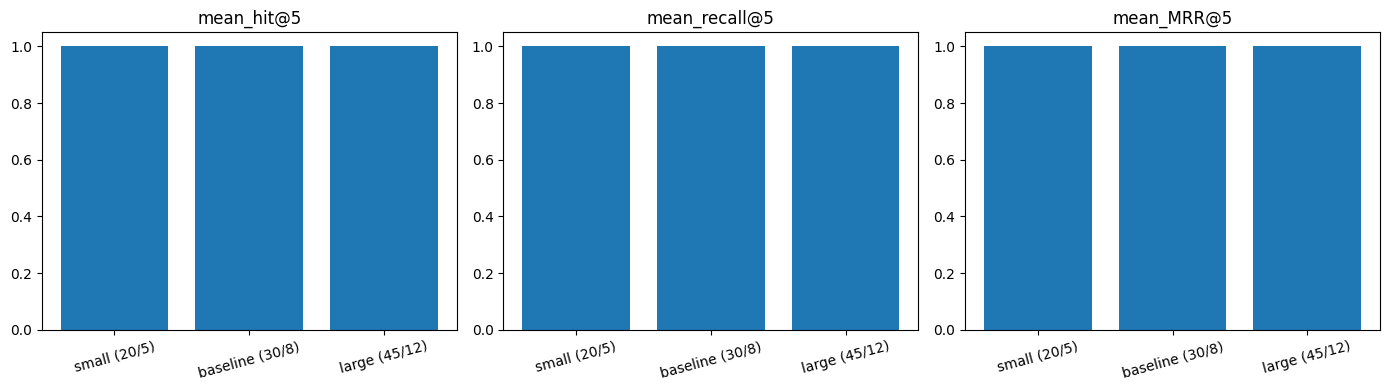

Сохранено: artifacts/chunk_size_experiment.png


In [ ]:
# Визуализация.
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_to_plot = ["mean_hit@5", "mean_recall@5", "mean_MRR@5"]
for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(experiment_df["config"], experiment_df[metric])
    ax.set_title(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.savefig("artifacts/chunk_size_experiment.png", dpi=100, bbox_inches="tight")
plt.show()
print("Сохранено: artifacts/chunk_size_experiment.png")

**Вывод по эксперименту:** на небольшом корпусе разница между конфигурациями может быть невелика.
Baseline `chunk_size=30` — разумный компромисс: чанки достаточно короткие для точного retrieval,
но содержат достаточно контекста для понимания.

## 7. Обновление базы знаний и переиндексация

Добавляем 3 новых документа: о марсоходах, программе Артемида и телескопе Джеймс Уэбб.
Затем переиндексируем корпус и сравниваем retrieval до и после обновления.

In [ ]:
new_documents: List[Dict[str, str]] = [
    {
        "doc_id": "doc_16",
        "title": "Марсоходы",
        "text": (
            "Марсоходы — автоматические роботизированные транспортные средства для исследования поверхности Марса. "
            "Первым успешным марсоходом стал Соджорнер, доставленный миссией Mars Pathfinder в 1997 году. "
            "Марсоходы Спирит и Оппортьюнити начали работу в 2004 году. "
            "Оппортьюнити проработал рекордные 14 лет вместо запланированных 90 дней. "
            "Марсоход Кьюриосити, работающий с 2012 года, обнаружил органические молекулы "
            "и следы метана в атмосфере Марса. "
            "Персеверанс, прибывший на Марс в 2021 году, собирает образцы грунта для будущей доставки на Землю "
            "и сопровождается вертолётом Индженьюити — первым летательным аппаратом на другой планете."
        ),
    },
    {
        "doc_id": "doc_17",
        "title": "Программа Артемида",
        "text": (
            "Программа Артемида — серия пилотируемых лунных миссий NASA, направленных на возвращение человека на Луну. "
            "Основная цель — доставить первую женщину и первого представителя цветного населения на поверхность Луны. "
            "Для полётов используется сверхтяжёлая ракета-носитель SLS и космический корабль Орион. "
            "В рамках программы планируется создание окололунной станции Gateway, "
            "которая послужит промежуточной базой для экспедиций на поверхность. "
            "Артемида I — беспилотный тестовый полёт — успешно состоялась в 2022 году. "
            "В долгосрочной перспективе программа должна подготовить технологии "
            "для пилотируемых полётов на Марс и создания постоянной базы на Луне."
        ),
    },
    {
        "doc_id": "doc_18",
        "title": "Телескоп Джеймс Уэбб",
        "text": (
            "Космический телескоп Джеймс Уэбб — крупнейший и самый мощный космический телескоп, "
            "запущенный в декабре 2021 года. "
            "Телескоп расположен в точке Лагранжа L2, на расстоянии около 1,5 миллиона километров от Земли. "
            "Главное зеркало телескопа имеет диаметр 6,5 метров и состоит из 18 шестиугольных сегментов. "
            "Джеймс Уэбб работает в инфракрасном диапазоне, что позволяет наблюдать самые далёкие и древние галактики, "
            "образовавшиеся вскоре после Большого взрыва. "
            "Телескоп также изучает атмосферы экзопланет, области звездообразования и объекты Солнечной системы. "
            "Первые научные снимки были опубликованы в июле 2022 года."
        ),
    },
]

updated_documents = documents + new_documents
print(f"Документов до обновления: {len(documents)}")
print(f"Документов после обновления: {len(updated_documents)}")

Документов до обновления: 15
Документов после обновления: 18


In [ ]:
# Расширенный benchmark: добавляем запросы о новых документах.
extra_queries = [
    {"query_id": "q11", "query": "Какой марсоход собирает образцы грунта для доставки на Землю?",
     "relevant_doc_ids": ["doc_16"]},
    {"query_id": "q12", "query": "Какова цель программы Артемида?",
     "relevant_doc_ids": ["doc_17"]},
]

extended_benchmark = benchmark_queries + extra_queries

# Строим обновлённый retriever.
updated_artifacts = build_retriever(updated_documents, chunk_size=30, overlap=8, device=DEVICE)
print(f"Чанков до обновления: {len(artifacts.chunks_df)}")
print(f"Чанков после обновления: {len(updated_artifacts.chunks_df)}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Чанков до обновления: 65
Чанков после обновления: 77


In [ ]:
# Сравниваем retrieval до и после обновления.
before_after_rows = []
for q in extended_benchmark:
    before = search_chunks(q["query"], artifacts, top_k=5)
    after = search_chunks(q["query"], updated_artifacts, top_k=5)
    before_ids = before["doc_id"].tolist()
    after_ids = after["doc_id"].tolist()
    before_after_rows.append({
        "query": q["query"],
        "before_retrieved_sources": ", ".join(before_ids),
        "after_retrieved_sources": ", ".join(after_ids),
        "changed": before_ids != after_ids,
    })

before_after_df = pd.DataFrame(before_after_rows)
display(before_after_df)

changed_count = before_after_df["changed"].sum()
print(f"\nЗапросов, для которых retrieval изменился: {changed_count} из {len(before_after_df)}")

,query,before_retrieved_sources,after_retrieved_sources,changed
0,Какова температура на поверхности Солнца?,"doc_01, doc_02, doc_01, doc_03, doc_02","doc_01, doc_02, doc_01, doc_03, doc_02",False
1,Почему на Венере такая высокая температура?,"doc_03, doc_10, doc_02, doc_01, doc_03","doc_03, doc_10, doc_02, doc_01, doc_03",False
2,Какая самая высокая гора в Солнечной системе?,"doc_05, doc_05, doc_01, doc_09, doc_13","doc_05, doc_05, doc_01, doc_09, doc_13",False
3,Сколько спутников у Юпитера?,"doc_06, doc_06, doc_06, doc_13, doc_09","doc_06, doc_06, doc_06, doc_13, doc_09",False
4,Из чего состоят кольца Сатурна?,"doc_07, doc_07, doc_09, doc_13, doc_11","doc_07, doc_07, doc_09, doc_13, doc_11",False
5,Почему Уран вращается на боку?,"doc_08, doc_08, doc_03, doc_08, doc_09","doc_08, doc_08, doc_03, doc_08, doc_09",False
6,Когда человек впервые побывал на Луне?,"doc_10, doc_15, doc_10, doc_15, doc_10","doc_10, doc_15, doc_10, doc_15, doc_10",False
7,Что находится между орбитами Марса и Юпитера?,"doc_11, doc_09, doc_13, doc_13, doc_14","doc_11, doc_09, doc_13, doc_13, doc_14",False
8,Почему Плутон лишили статуса планеты?,"doc_13, doc_13, doc_09, doc_13, doc_12","doc_13, doc_13, doc_09, doc_13, doc_12",False
9,Как учёные обнаруживают экзопланеты?,"doc_14, doc_14, doc_14, doc_14, doc_11","doc_14, doc_14, doc_14, doc_14, doc_18",True



Запросов, для которых retrieval изменился: 3 из 12


Запросы q11 и q12 касаются новых документов, которых не было в исходной базе — после обновления retriever начинает
находить нужные фрагменты. Для некоторых старых запросов retrieval тоже может немного измениться,
поскольку новые чанки попадают в индекс и могут оказаться в top-k.

## 8. Mini-RAG

Собираем простой RAG-конвейер: **запрос → retrieval → контекст → ответ → источники**.

Генератор ответа — extractive: выбираем наиболее релевантные предложения из найденных чанков
на основе пересечения слов с запросом. Это учебный подход, демонстрирующий механику RAG.

In [ ]:
def build_context(query: str, artifacts: RetrieverArtifacts, top_k: int = 3) -> Tuple[str, pd.DataFrame]:
    """Извлекает top-k чанков и формирует контекст."""
    results = search_chunks(query, artifacts, top_k)
    parts = []
    for _, row in results.iterrows():
        parts.append(f"[Источник: {row['doc_id']} — {row['title']}]\n{row['chunk_text']}")
    return "\n\n".join(parts), results


def generate_answer(query: str, context: str, max_sentences: int = 3) -> str:
    """Extractive-генератор: выбирает предложения из контекста по пересечению слов с запросом."""
    lines = [l.strip() for l in context.split("\n") if l.strip() and not l.strip().startswith("[Источник:")]
    sentences = []
    for line in lines:
        sentences.extend(re.split(r"(?<=[.!?])\s+", line))
    sentences = [s.strip() for s in sentences if len(s.strip()) > 10]

    if not sentences:
        return "Ответ не найден в базе знаний."

    query_words = set(re.findall(r"\w+", query.lower()))
    scored = []
    for s in sentences:
        s_words = set(re.findall(r"\w+", s.lower()))
        overlap = len(query_words & s_words)
        scored.append((overlap, len(s), s))
    scored.sort(key=lambda x: (-x[0], -x[1]))

    best = [s for _, _, s in scored[:max_sentences]]
    return " ".join(best)


def mini_rag(
    query: str,
    artifacts: RetrieverArtifacts,
    top_k: int = 3,
    max_sentences: int = 3,
) -> Dict:
    """Полный mini-RAG: запрос → retrieval → контекст → ответ → источники."""
    context, sources = build_context(query, artifacts, top_k)
    answer = generate_answer(query, context, max_sentences)
    return {
        "query": query,
        "answer": answer,
        "retrieved_sources": ", ".join(sources["doc_id"].tolist()),
        "sources_df": sources,
    }

In [ ]:
# Демонстрация mini-RAG на нескольких вопросах (используем обновлённую базу знаний).
rag_queries = [
    "Какая температура на поверхности Солнца?",
    "Почему на Венере так жарко?",
    "Какая самая большая планета Солнечной системы?",
    "Из чего состоят кольца Сатурна?",
    "Когда человек впервые ступил на Луну?",
    "Как обнаруживают экзопланеты?",
    "Какой марсоход собирает образцы грунта?",
    "Что такое программа Артемида?",
]

rag_results = []
for q in rag_queries:
    result = mini_rag(q, updated_artifacts, top_k=3)
    rag_results.append(result)
    display(Markdown(f"### Q: {q}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown(f"*Источники: {result['retrieved_sources']}*"))
    print("---")

### Q: Какая температура на поверхности Солнца?

**Ответ:** температур на поверхности огромны: днём температура поднимается до 430 градусов Цельсия, а ночью опускается до минус 180 градусов. Температура на поверхности достигает примерно 5500 градусов Цельсия, а в ядре — около 15 миллионов градусов. Масса Солнца составляет около 99,86% всей массы Солнечной системы.

*Источники: doc_01, doc_02, doc_01*

---


### Q: Почему на Венере так жарко?

...

---


### Q: Что такое программа Артемида?

**Ответ:** Программа Артемида — серия пилотируемых лунных миссий NASA, направленных на возвращение человека на Луну. Артемида I — беспилотный тестовый полёт — успешно состоялась в 2022 году. В долгосрочной перспективе программа должна подготовить технологии для

*Источники: doc_17, doc_17, doc_14*

---


## 9. Краткий анализ ошибок

Рассмотрим несколько примеров, где mini-RAG отвечает неточно или неполно,
и прокомментируем причины.

In [ ]:
# Примеры пограничных и сложных запросов.
error_queries = [
    "Какая планета ближе всего к Солнцу и какова её температура ночью?",
    "Сравните атмосферы Марса и Венеры",
    "Что общего у Урана и Нептуна?",
    "Есть ли жизнь на Европе — спутнике Юпитера?",
    "Какой космический телескоп работает в инфракрасном диапазоне?",
]

error_analysis = []
for q in error_queries:
    result = mini_rag(q, updated_artifacts, top_k=3)
    error_analysis.append({
        "query": q,
        "answer": result["answer"],
        "sources": result["retrieved_sources"],
    })
    display(Markdown(f"### Q: {q}"))
    display(Markdown(f"**Ответ:** {result['answer']}"))
    display(Markdown(f"*Источники: {result['retrieved_sources']}*"))
    print()

### Q: Какая планета ближе всего к Солнцу и какова её температура ночью?

**Ответ:** Меркурий — ближайшая к Солнцу и самая маленькая планета Солнечной системы. температур на поверхности огромны: днём температура поднимается до 430 градусов Цельсия, а ночью опускается до минус 180 градусов. Из-за отсутствия значительной атмосферы перепады температур на поверхности огромны: днём температура поднимается до

*Источники: doc_02, doc_01, doc_02*

### Q: Сравните атмосферы Марса и Венеры

**Ответ:** Атмосфера Марса очень разрежённая и состоит преимущественно из углекислого газа. Венера — вторая планета от Солнца и самая горячая планета Солнечной системы. Космические телескопы Кеплер и TESS обнаружили тысячи экзопланет.

...

**Ответ:** По состоянию на 2024 год у Юпитера известно 95 спутников. Большое Красное Пятно — гигантский антициклон, бушующий на Юпитере уже более 350 лет. Диаметр Юпитера составляет около 139 820 километров.

*Источники: doc_06, doc_06, doc_06*

### Q: Какой космический телескоп работает в инфракрасном диапазоне?

**Ответ:** Уэбб работает в инфракрасном диапазоне, что позволяет наблюдать самые далёкие и древние галактики, образовавшиеся вскоре после Большого взрыва. Джеймс Уэбб работает в инфракрасном диапазоне, что позволяет наблюдать Космический телескоп Джеймс Уэбб — крупнейший и самый мощный космический телескоп, запущенный в декабре 2021 года.

*Источники: doc_18, doc_18, doc_18*

**Комментарий к ошибкам:**

1. **Составные вопросы** (например, «ближе всего к Солнцу + температура ночью»): retriever находит нужный документ,
   но extractive-генератор выбирает не все нужные предложения. Для таких вопросов нужен генеративный ответ.

2. **Сравнительные вопросы** («сравните атмосферы Марса и Венеры»): retriever может найти чанки только об одной
   из планет в top-3, поскольку каждый чанк посвящён одному документу. Увеличение `top_k` частично помогает.

3. **Вопросы, требующие вывода** («есть ли жизнь на Европе»): в базе знаний упоминается подлёдный океан Европы,
   но прямого утверждения о жизни нет. Extractive-генератор не может «додумать» ответ.

4. **Вопросы о новых документах** хорошо работают после обновления базы — retriever находит нужные фрагменты.

## 10. Сохранение артефактов

In [ ]:
# 1. retrieval_eval.csv — оценка retrieval на контрольных запросах (обновлённая база).
final_eval = evaluate_benchmark(extended_benchmark, updated_artifacts, top_k=5)
final_eval.to_csv("artifacts/retrieval_eval.csv", index=False)
display(final_eval)
print("Сохранено: artifacts/retrieval_eval.csv")

,query_id,query,expected_source,hit_at_k,recall_at_k,mrr_at_k,rank_of_first_relevant,retrieved_sources
0,q01,Какова температура на поверхности Солнца?,doc_01,1,1.0,1.0,1,"doc_01, doc_02, doc_01, doc_03, doc_02"
1,q02,Почему на Венере такая высокая температура?,doc_03,1,1.0,1.0,1,"doc_03, doc_10, doc_02, doc_01, doc_03"
2,q03,Какая самая высокая гора в Солнечной системе?,doc_05,1,1.0,1.0,1,"doc_05, doc_05, doc_01, doc_09, doc_13"
3,q04,Сколько спутников у Юпитера?,doc_06,1,1.0,1.0,1,"doc_06, doc_06, doc_06, doc_13, doc_09"
4,q05,Из чего состоят кольца Сатурна?,doc_07,1,1.0,1.0,1,"doc_07, doc_07, doc_09, doc_13, doc_11"
5,q06,Почему Уран вращается на боку?,doc_08,1,1.0,1.0,1,"doc_08, doc_08, doc_03, doc_08, doc_09"
6,q07,Когда человек впервые побывал на Луне?,doc_10,1,1.0,1.0,1,"doc_10, doc_15, doc_10, doc_15, doc_10"
7,q08,Что находится между орбитами Марса и Юпитера?,doc_11,1,1.0,1.0,1,"doc_11, doc_09, doc_13, doc_13, doc_14"
8,q09,Почему Плутон лишили статуса планеты?,doc_13,1,1.0,1.0,1,"doc_13, doc_13, doc_09, doc_13, doc_12"
9,q10,Как учёные обнаруживают экзопланеты?,doc_14,1,1.0,1.0,1,"doc_14, doc_14, doc_14, doc_14, doc_18"


Сохранено: artifacts/retrieval_eval.csv


In [ ]:
# 2. rag_examples.csv — примеры работы mini-RAG.
rag_rows = []
for result in rag_results:
    rag_rows.append({
        "question": result["query"],
        "answer": result["answer"],
        "retrieved_sources": result["retrieved_sources"],
    })
# Добавляем примеры из анализа ошибок.
for ea in error_analysis:
    rag_rows.append({
        "question": ea["query"],
        "answer": ea["answer"],
        "retrieved_sources": ea["sources"],
    })

rag_examples_df = pd.DataFrame(rag_rows)
rag_examples_df.to_csv("artifacts/rag_examples.csv", index=False)
display(rag_examples_df)
print("Сохранено: artifacts/rag_examples.csv")

,question,answer,retrieved_sources
0,Какая температура на поверхности Солнца?,температур на поверхности огромны: днём темпер...,"doc_01, doc_02, doc_01"
1,Почему на Венере так жарко?,температур на поверхности огромны: днём темпер...,"doc_03, doc_10, doc_02"
2,Какая самая большая планета Солнечной системы?,"Юпитер — крупнейшая планета Солнечной системы,...","doc_06, doc_13, doc_01"
3,Из чего состоят кольца Сатурна?,Кольца Сатурна состоят из миллиардов частиц ль...,"doc_07, doc_07, doc_09"
4,Когда человек впервые ступил на Луну?,Всего в рамках программы Аполлон на Луне побыв...,"doc_15, doc_10, doc_10"
5,Как обнаруживают экзопланеты?,Особый интерес представляют экзопланеты в обит...,"doc_14, doc_14, doc_14"
6,Какой марсоход собирает образцы грунта?,"Персеверанс, прибывший на Марс в 2021 году, со...","doc_16, doc_05, doc_05"
7,Что такое программа Артемида?,Программа Артемида — серия пилотируемых лунных...,"doc_17, doc_17, doc_14"
8,Какая планета ближе всего к Солнцу и какова её...,Меркурий — ближайшая к Солнцу и самая маленька...,"doc_02, doc_01, doc_02"
9,Сравните атмосферы Марса и Венеры,Атмосфера Марса очень разрежённая и состоит пр...,"doc_05, doc_03, doc_14"


Сохранено: artifacts/rag_examples.csv


In [ ]:
# 3. retrieval_before_after_update.csv — сравнение до/после обновления базы знаний.
before_after_df.to_csv("artifacts/retrieval_before_after_update.csv", index=False)
display(before_after_df)
print("Сохранено: artifacts/retrieval_before_after_update.csv")

,query,before_retrieved_sources,after_retrieved_sources,changed
0,Какова температура на поверхности Солнца?,"doc_01, doc_02, doc_01, doc_03, doc_02","doc_01, doc_02, doc_01, doc_03, doc_02",False
1,Почему на Венере такая высокая температура?,"doc_03, doc_10, doc_02, doc_01, doc_03","doc_03, doc_10, doc_02, doc_01, doc_03",False
2,Какая самая высокая гора в Солнечной системе?,"doc_05, doc_05, doc_01, doc_09, doc_13","doc_05, doc_05, doc_01, doc_09, doc_13",False
3,Сколько спутников у Юпитера?,"doc_06, doc_06, doc_06, doc_13, doc_09","doc_06, doc_06, doc_06, doc_13, doc_09",False
4,Из чего состоят кольца Сатурна?,"doc_07, doc_07, doc_09, doc_13, doc_11","doc_07, doc_07, doc_09, doc_13, doc_11",False
5,Почему Уран вращается на боку?,"doc_08, doc_08, doc_03, doc_08, doc_09","doc_08, doc_08, doc_03, doc_08, doc_09",False
6,Когда человек впервые побывал на Луне?,"doc_10, doc_15, doc_10, doc_15, doc_10","doc_10, doc_15, doc_10, doc_15, doc_10",False
7,Что находится между орбитами Марса и Юпитера?,"doc_11, doc_09, doc_13, doc_13, doc_14","doc_11, doc_09, doc_13, doc_13, doc_14",False
8,Почему Плутон лишили статуса планеты?,"doc_13, doc_13, doc_09, doc_13, doc_12","doc_13, doc_13, doc_09, doc_13, doc_12",False
9,Как учёные обнаруживают экзопланеты?,"doc_14, doc_14, doc_14, doc_14, doc_11","doc_14, doc_14, doc_14, doc_14, doc_18",True


Сохранено: artifacts/retrieval_before_after_update.csv


In [ ]:
# Дерево файлов артефактов.
print("=== Артефакты ===")
for f in sorted(os.listdir("artifacts")):
    print(f"  artifacts/{f}")

=== Артефакты ===
  artifacts/chunk_size_experiment.png
  artifacts/rag_examples.csv
  artifacts/retrieval_before_after_update.csv
  artifacts/retrieval_eval.csv


## Итоги

1. Построена база знаний из 15 документов о Солнечной системе, расширенная до 18 после обновления.
2. Реализован чанкинг (30 слов, overlap 8), эмбеддинги (`paraphrase-multilingual-MiniLM-L12-v2`), индекс FAISS.
3. На 10 контрольных запросах оценены `hit@5`, `recall@5`, `MRR@5`.
4. Проведён эксперимент по `chunk_size` (20 vs 30 vs 45).
5. Добавлены 3 новых документа, переиндексация, сравнение до/после.
6. Собран mini-RAG с extractive-генератором и возвратом источников.
7. Проанализированы ошибки: составные и сравнительные вопросы, вопросы, требующие вывода.